# Классическое машинное обучение

### Семинар 7. Методы снижения размерности - часть 2.

**Предупреждение**: как обычно, **<font color="red">самописными структурами красно-черных деревьев пользоваться запрещено!</font>**

In [ ]:
!pip install umap-learn > /dev/null

In [ ]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
sns.set_style("ticks")

### Задача 1 (1 балл)

Произведите отбор признаков с помощью PCA.
Для этого отберите 3 признака, наиболее сильно повлиявших на первую компоненту.

In [ ]:
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/introduction/data/breast_cancer_wisconsin.csv -O breast_cancer_wisconsin.csv

--2026-04-08 16:49:32--  https://data.bioml.ru/htdocs/courses/bioml/classic_ml/introduction/data/breast_cancer_wisconsin.csv
Resolving data.bioml.ru (data.bioml.ru)... 188.120.231.217
Connecting to data.bioml.ru (data.bioml.ru)|188.120.231.217|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 125203 (122K) [text/csv]
Saving to: ‘breast_cancer_wisconsin.csv’

breast_cancer_wisco 100%[===================>] 122.27K   392KB/s    in 0.3s    

2026-04-08 16:49:34 (392 KB/s) - ‘breast_cancer_wisconsin.csv’ saved [125203/125203]



In [ ]:
data = pd.read_csv("breast_cancer_wisconsin.csv", index_col=0)
X = data.iloc[:, 1:]

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sc = StandardScaler()
X_sc = sc.fit_transform(X)
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_sc)


In [ ]:
dir(pca)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_n_features',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_fit',
 '_fit_full',
 '_fit_svd_solver',
 '_fit_truncated',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_more_tags',
 '_n_features_out',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_sklearn_auto_wrap_output_keys',
 '_transform',

In [ ]:
components = pd.Series(pca.components_[0], index = X.columns)
components.sort_values(ascending=False)

,0
concave points_mean,0.260854
concavity_mean,0.258400
concave points_worst,0.250886
compactness_mean,0.239285
perimeter_worst,0.236640
concavity_worst,0.228768
radius_worst,0.227997
perimeter_mean,0.227537
area_worst,0.224871
area_mean,0.220995


### Задача 2 (1 балл)

За вас написана команда для скачивания датасета.

Подберите гиперпараметры алгоритма t-SNE или UMAP так, чтобы было видно присутствующие в данных кластеры. Сколько их?

Обратите внимание: дополнительных преобразований к данным применять **не нужно**!

In [ ]:
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/dimred_small_X.npy -O dimred_small_X.npy

--2026-04-08 16:50:16--  https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/dimred_small_X.npy
Resolving data.bioml.ru (data.bioml.ru)... 188.120.231.217
Connecting to data.bioml.ru (data.bioml.ru)|188.120.231.217|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 32128 (31K)
Saving to: ‘dimred_small_X.npy’

dimred_small_X.npy  100%[===================>]  31.38K  --.-KB/s    in 0s      

2026-04-08 16:50:17 (272 MB/s) - ‘dimred_small_X.npy’ saved [32128/32128]



In [ ]:
X = np.load("dimred_small_X.npy")

In [ ]:
from sklearn.manifold import TSNE

sc = StandardScaler()
X_sc = sc.fit_transform(X)
tsne = TSNE(n_components=2, perplexity = 5)

X_tsne = tsne.fit_transform(X_sc)


<Axes: >

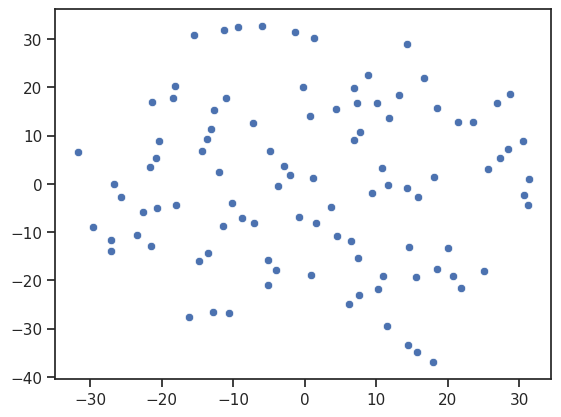

In [ ]:
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:,1])

### Задача 3 (1 балл)

Задача состоит из нескольких шагов:

1. Загрузите данные. Обучите модель логистической регрессии с L1-регуляризацией на этих данных для предсказания `y`, оцените качество модели.
2. Примените [`PLSRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.cross_decomposition.PLSRegression.html) для поиска эффективного пространства для разделения двух групп. Задайте пространство двумерным.
3. Нарисуйте график, на котором показано, как разделяются эти две группы.
4. Обучите логистическую регрессию на выделенных компонентах. Удалось ли улучшить качество?
5. Оцените долю объясненной дисперсии в выделенных компонентах. Что вы видите?

In [ ]:
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/dimred_example_X.npy -O dimred_example_X.npy
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/dimred_example_y.npy -O dimred_example_y.npy

--2026-04-08 16:50:28--  https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/dimred_example_X.npy
Resolving data.bioml.ru (data.bioml.ru)... 188.120.231.217
Connecting to data.bioml.ru (data.bioml.ru)|188.120.231.217|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24000128 (23M)
Saving to: ‘dimred_example_X.npy’

dimred_example_X.np 100%[===================>]  22.89M  10.5MB/s    in 2.2s    

2026-04-08 16:50:31 (10.5 MB/s) - ‘dimred_example_X.npy’ saved [24000128/24000128]

--2026-04-08 16:50:31--  https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/dimred_example_y.npy
Resolving data.bioml.ru (data.bioml.ru)... 188.120.231.217
Connecting to data.bioml.ru (data.bioml.ru)|188.120.231.217|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16128 (16K)
Saving to: ‘dimred_example_y.npy’

dimred_example_y.np 100%[===================>]  15.75K  --.-KB/s    in 0s      

2026-04

In [ ]:
X = np.load("dimred_example_X.npy")
y = np.load("dimred_example_y.npy")

In [ ]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y)

plsr = PLSRegression(n_components=2)
X_train_plsr, _ = plsr.fit_transform(X_train, y_train)

<Axes: >

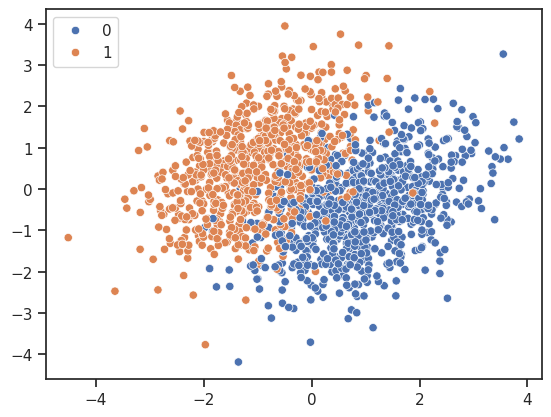

In [ ]:
sns.scatterplot(x=X_train_plsr[:,0], y=X_train_plsr[:,1], hue=y_train)

In [ ]:
X_test_plsr = plsr.transform(X_test)

<Axes: >

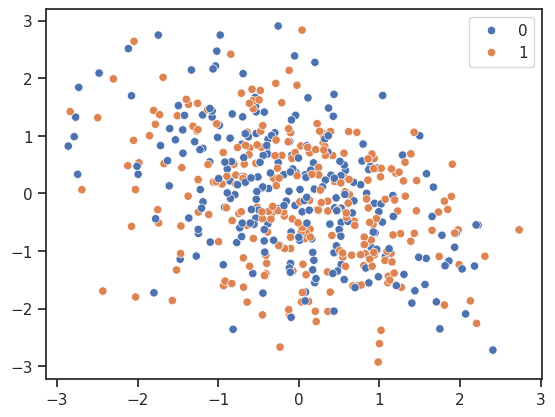

In [ ]:
sns.scatterplot(x=X_test_plsr[:,0], y=X_test_plsr[:,1], hue=y_test)

### Задача 4 (2 балла)

Воспользуйтесь датасетом с фентезийными мирами из прошлого занятия.

1. Возьмите верхнюю часть **не более 10%** от выборки для обучения модели `PLSRegression` с 2 компонентами на этих данных, используя информацию из `y`. Примените выученное линейное преобразование к оставшимся 90% данных.

2. Попробуйте проделать то же самое, закодировав `y` с помощью one-hot encoding (для этого проще всего использовать `pd.get_dummies`). Стала ли визуализация лучше? Почему?

2. Определите признаки, которые оказались наиболее важными по версии PLS.

3. Обучите на представлениях точек в новом базисе кластеризацию KMeans (или NMF - для интересующихся!).

4. Примените к полученным кластерам LDA и визуализируйте по аналогии с [примером из документации Sklearn](https://scikit-learn.org/stable/auto_examples/classification/plot_lda_qda.html#comparison-of-lda-and-qda).

In [ ]:
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/realmdata.parquet -O realmdata.parquet

--2026-04-08 16:50:47--  https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/realmdata.parquet
Resolving data.bioml.ru (data.bioml.ru)... 188.120.231.217
Connecting to data.bioml.ru (data.bioml.ru)|188.120.231.217|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 55941 (55K)
Saving to: ‘realmdata.parquet’

realmdata.parquet   100%[===================>]  54.63K   353KB/s    in 0.2s    

2026-04-08 16:50:49 (353 KB/s) - ‘realmdata.parquet’ saved [55941/55941]



In [ ]:
df = pd.read_parquet("realmdata.parquet")
X = df.iloc[:, 1:]
y = df['DIMENSION']
df.head(3).T.head(10)

,0,1,2
DIMENSION,3.000,0.000,3.000
aeggiogar,-17.570,-10.602,4.439
aegrunia,-24.742,-39.517,-19.997
aerrurion,-4.737,-8.569,-2.725
bizarea,-3.020,-47.248,-26.740
caesserant,3.704,-13.695,17.792
cliokorynn,3.338,10.401,1.458
creatinia,-19.038,-8.970,26.582
driodiorion,11.178,25.480,2.312
drioxiroth,-21.129,-39.400,-25.667


In [ ]:
n = 10  # Increase this if this doesn't work properly
X_train, X_test = X.iloc[:n], X.iloc[n:]
y_train, y_test = y.iloc[:n], y.iloc[n:]

In [ ]:
plsr = PLSRegression(n_components=2)
X_train_plsr, _ = plsr.fit_transform(X_train, y_train)

In [ ]:
X_test_plsr = plsr.transform(X_test)

<Axes: >

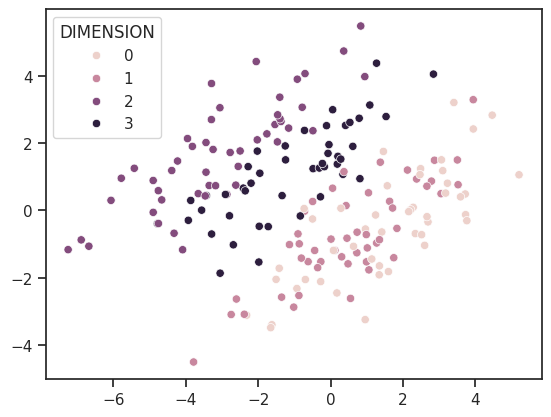

In [ ]:
sns.scatterplot(x=X_test_plsr[:,0], y=X_test_plsr[:,1], hue=y_test)

In [ ]:
y_train_one_hot = pd.get_dummies(y_train).astype(float).values

In [ ]:
plsr = PLSRegression(n_components=2)
X_train_plsr_oh, _ = plsr.fit_transform(X_train, y_train_one_hot)
X_test_plsr_oh = plsr.transform(X_test)


<Axes: >

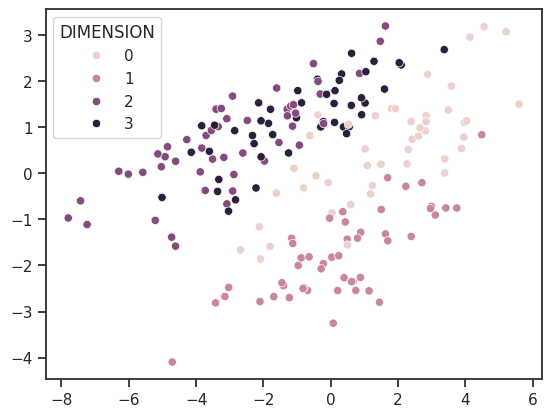

In [ ]:
sns.scatterplot(x=X_test_plsr_oh[:, 0], y=X_test_plsr_oh[:, 1], hue=y_test)

In [ ]:
x = np.random.normal(0, 5, size=(1000,))
y = (x + 20) // 10

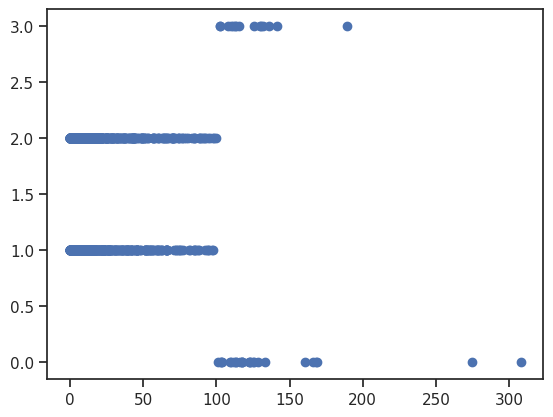

In [ ]:
plt.scatter(x ** 2, y)

In [ ]:
import scipy as sp

sp.stats.pearsonr(x ** 2, y)

PearsonRResult(statistic=np.float64(-0.11410975902005384), pvalue=np.float64(0.0002994555814588706))

In [ ]:
df = pd.get_dummies(y.astype(int)).astype(int)
df['x'] = x ** 2
df['y'] = y

In [ ]:
df

,0,1,2,3,x,y
0,0,1,0,0,0.201979,1.0
1,0,0,1,0,28.652183,2.0
2,0,1,0,0,4.470585,1.0
3,0,0,1,0,50.870370,2.0
4,0,0,1,0,69.996776,2.0
...,...,...,...,...,...,...
995,0,1,0,0,6.245082,1.0
996,0,0,1,0,8.325619,2.0
997,0,1,0,0,1.639319,1.0
998,0,0,1,0,37.356900,2.0


In [ ]:
df.corr()

,0,1,2,3,x,y
0,1.000000,-0.156033,-0.157603,-0.020162,0.566621,-0.421488
1,-0.156033,1.000000,-0.921228,-0.117852,-0.137370,-0.805756
2,-0.157603,-0.921228,1.000000,-0.119038,-0.135195,0.860758
3,-0.020162,-0.117852,-0.119038,1.000000,0.378409,0.324349
x,0.566621,-0.137370,-0.135195,0.378409,1.000000,-0.114110
y,-0.421488,-0.805756,0.860758,0.324349,-0.114110,1.000000


In [ ]:
#loadings показывают, какой вклад каждый исходный признак вносит в PLS-компоненты
loadings = plsr.x_loadings_
#вычисляем важность каждого признака как сумму абсолютных значений нагрузок
feature_importance = np.abs(loadings).sum(axis=1)
feature_names = X.columns

In [ ]:
#сортируем индексы признаков по убыванию важности
sorted_idx = np.argsort(feature_importance)[::-1]
#берем топ-15 самых важных признаков
top_features_list = feature_names[sorted_idx[:15]].tolist()
print("Самые важные признаки:")
print(top_features_list)

Самые важные признаки:
['flaejeotope', 'sleqerune', 'waexearant', 'bizarea', 'cliokorynn', 'aerrurion', 'mappaven', 'ioqatopia', 'wreojighar', 'niglomelan', 'piammeabis', 'drioxiroth', 'driodiorion', 'caesserant', 'aeggiogar']


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [ ]:
#масштабируем данные
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)

In [ ]:
X_transformed = X_test_plsr_oh
#количество кластеров(можно взять количество уникальных классов)
n_clusters = len(np.unique(y_test))

#обучаем KMeans
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_transformed)

In [ ]:
#обучение LDA на предсказанных кластерах
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_test_scaled, clusters)

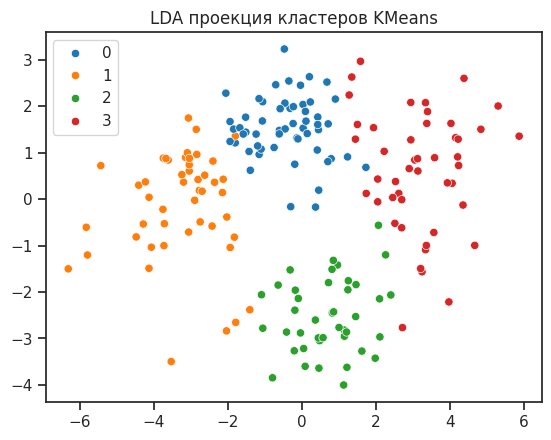

In [ ]:
sns.scatterplot(x=X_lda[:, 0], y=X_lda[:, 1], hue=clusters, palette='tab10')
plt.title('LDA проекция кластеров KMeans')
plt.show()

### Задача 5 (2.5 балла)

Для вас загружен датасет по данным секвенирования одиночных клеток [[источник](https://doi.org/10.1101/2021.09.16.460628) датасета]. Датасет уже предобработан, дополнительную предобработку (например, стандартизацию) осуществлять не нужно.

Подберите параметры UMAP таким образом, чтобы по данным получались наилучшие кластеры из атрибута `cell_type` (см. метаданные). Придумайте <u>количественный</u> способ оценки получаемого пространства (известная разметка на кластеры в этом пространстве должна быть хорошей). Попробуйте различные параметры UMAP и добейтесь улучшения вашей функции качества относительно запуска с параметрами по умолчанию.

In [ ]:
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/singlecell/expression_data.npz -O expression_data.npz -q
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/singlecell/metadata_row.parquet -O metadata_row.parquet -q
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/singlecell/metadata_col.parquet -O metadata_col.parquet -q

In [ ]:
data = sp.sparse.load_npz('expression_data.npz')
meta_row = pd.read_parquet('metadata_row.parquet')
meta_col = pd.read_parquet('metadata_col.parquet')
data.shape, meta_row.shape, meta_col.shape

((50753, 1000), (50753, 4), (1000, 2))

In [ ]:
y_train_one_hot = pd.get_dummies(y_train).astype(float)

Что может получиться:

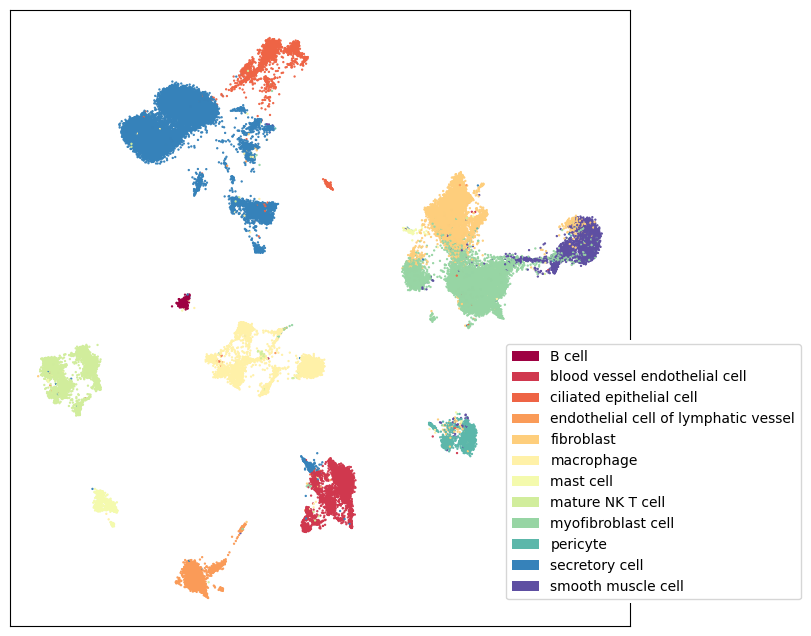

In [ ]:
import umap
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
y = meta_row['cell_type'].values
y

['secretory cell', 'secretory cell', 'ciliated epithelial cell', 'blood vessel endothelial cell', 'mature NK T cell', ..., 'macrophage', 'macrophage', 'myofibroblast cell', 'endothelial cell of lymphatic vessel', 'myofibroblast cell']
Length: 50753
Categories (12, object): ['fibroblast', 'ciliated epithelial cell',
                          'blood vessel endothelial cell', 'mast cell', ..., 'B cell', 'pericyte', 'mature NK T cell',
                          'endothelial cell of lymphatic vessel']

In [ ]:
params = [
    (15, 0.1),   # default
    (30, 0.1),
    (50, 0.1),
    (15, 0.05),  # более плотные кластеры
    (30, 0.05),
    (50, 0.05),
    (15, 0.5),   # более разреженные кластеры
    (30, 0.5),
    (50, 0.5),
]

aris = []
embeddings = []

print("Поиск лучших параметров UMAP")
for i, (n, d) in enumerate(params, 1):
    print(f"{i}/{len(params)}: n_neighbors={n}, min_dist={d}")

    umap_model = umap.UMAP(n_neighbors=n, min_dist=d, random_state=42)
    emb = umap_model.fit_transform(data)
    embeddings.append(emb)

    kmeans = KMeans(n_clusters=len(set(y)), random_state=42, n_init=10)
    labels = kmeans.fit_predict(emb)

    ari = adjusted_rand_score(y, labels)
    aris.append(ari)
    print(f"  ARI = {ari:.4f}\n")

Поиск лучших параметров UMAP
1/9: n_neighbors=15, min_dist=0.1
  ARI = 0.7952

2/9: n_neighbors=30, min_dist=0.1


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  ARI = 0.8099

3/9: n_neighbors=50, min_dist=0.1


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  ARI = 0.8256

4/9: n_neighbors=15, min_dist=0.05


...

  ARI = 0.6711

8/9: n_neighbors=30, min_dist=0.5


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  ARI = 0.7565

9/9: n_neighbors=50, min_dist=0.5


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  ARI = 0.8023



Лучший результат - тест 3, ari - самое высокое значение


In [ ]:
best_idx = np.argmax(aris)
best_params = params[best_idx]
best_emb = embeddings[best_idx]
best_ari = aris[best_idx]


In [ ]:
print("Лучший результат:")
n_neigh=best_params[0]
min_dist=best_params[1]
n_neigh, min_dist

Лучший результат:


(50, 0.1)

In [ ]:
ari = max(aris)
ari


0.8255733686488622

In [ ]:
ar = (max(aris)-aris[0])/aris[0]*100
print(f"улучшение: {ar}")

улучшение: 3.816986529869626


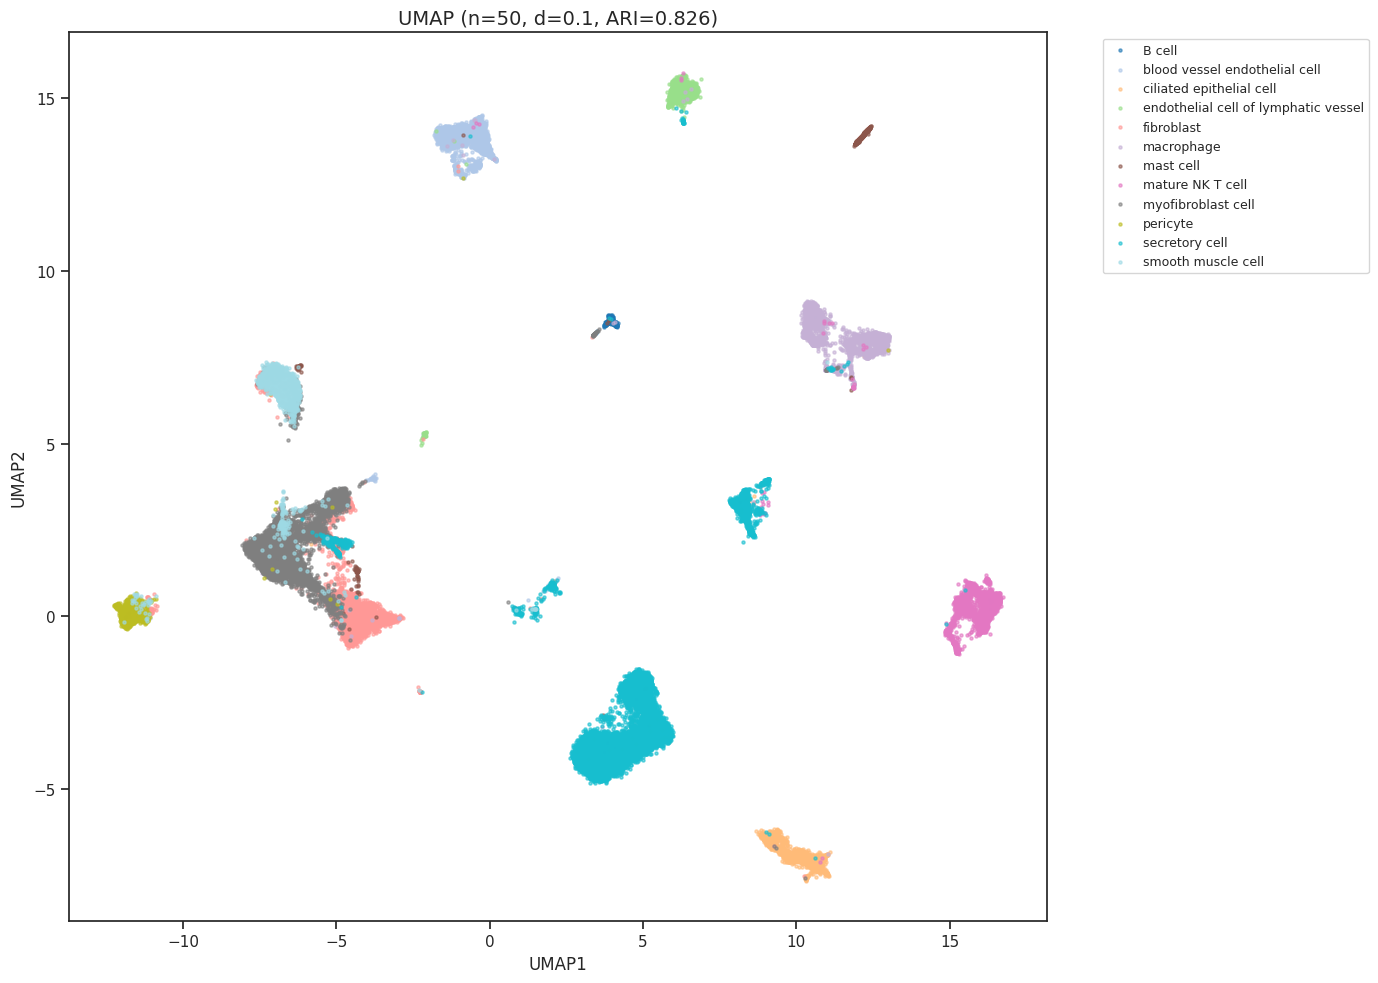

In [ ]:
plt.figure(figsize=(14, 10))

#уникальные типы клеток визуализируем
unique_types = np.unique(y)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_types)))

#каждый тип отдельно рисую
for i, cell_type in enumerate(unique_types):
    mask = y == cell_type
    plt.scatter(best_emb[mask, 0], best_emb[mask, 1],
                c=[colors[i]], label=cell_type, s=5, alpha=0.6)

plt.title(f'UMAP (n={best_params[0]}, d={best_params[1]}, ARI={best_ari:.3f})', fontsize=14)
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

На представленной визуализации видно разделение на кластеры, соответствующих различным типам клеток. Кластеры хорошо изолированы друг от друга, а это  подтверждается высоким значением ARI = 0.82, при этом мы видим что разделение на кластеры произошло не очень качественно, так как элементы из одного кластера есть в другом кластере. Но, в целом, это можно объяснить шумом в данных, или в том, что клетки биологически схожи.

### Задача 6 (3 балла)

В популяционной генетике одной из ключевых задач является выявление взаимоотношений между индивидами и популяциями. Традиционные подходы снижения размерности работают непосредственно с генотипами, переводя их в матрицы расстояний, где для каждого индивида рассчитано его генетическое расстояние до другого. Это называется IBS (identical-by-state) подход, и расстояние между индивидами считается как сумма следующей метрики по всем SNP на хромосоме: $d(I_1, I_2)_{SNP_i} = | Dose(I_1, SNP_i) - Dose(I_2, SNP_i) |$, то есть разница в *дозировке* полиморфизма, т.е. количестве альтернативных аллелей (0 - референсная гомозигота, 1 - гетерозигота, 2 - альтернативная гомозигота, без учёта фазирования).

Известно, что популяционная генетика может помогать в криминалистике путём определения популяционной принадлежности преступника. В этой задаче давайте оценим границы применения методов предсказания популяционной принадлежности преступника на данных популяционных меток проекта 1000 genomes, за вас выполнен подсчёт матрицы расстояний. Попробуйте научить `PLSregression` на суперпопуляционных тегах (AMR, AFR, SAS, EAS, EUR) и на интрапопуляционных тегах (GBR, YRI, PUR, и др.). Оцените качество полученных моделей, визуализируйте в пространстве первых 2 компонент.

Посчитайте объяснённые дисперсии для признаков X и $r^2$ для y. Что вы видите?

In [ ]:
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/supervised/plsr/population_metadata_phase3.tsv -O population_metadata_phase3.tsv -q
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/supervised/plsr/chr15.distances.mdist.tsv -O chr15.distances.mdist.tsv -q
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/supervised/plsr/chr15.distances.id.tsv -O chr15.distances.id.tsv -q

In [ ]:
def load_plink_mdist_to_dataframe(mdist_path, id_path):
    ids_df = pd.read_csv(id_path, sep='\\s+', header=None)
    ids_df['Sample'] = ids_df[0].astype(str)

    sample_ids = ids_df['Sample'].astype(str).tolist()
    n_samples = len(sample_ids)

    with open(mdist_path, 'r') as f:
        lines = [float(d) for line in f.readlines() for d in line.strip().split(' ')]
        dist_array = np.array(lines).reshape(n_samples, n_samples)
    dist_df = pd.DataFrame(dist_array, index=sample_ids, columns=sample_ids)

    return dist_df


def load_annotation(annot_path):
    annot_df = pd.read_csv(annot_path, sep='\t')
    annot_df['Sample'] = annot_df['Sample'].astype(str)
    annot_df = annot_df.set_index('Sample')
    return annot_df


def get_dataset(mdist_path, id_path, annot_path, target="Superpopulation"):
    dist_df = load_plink_mdist_to_dataframe(mdist_path, id_path)
    annot_df = load_annotation(annot_path)
    common_samples = dist_df.index.intersection(annot_df.index)
    dist_df_aligned = dist_df.loc[common_samples].copy()
    annot_df_aligned = annot_df.loc[common_samples].copy()
    X = dist_df_aligned.copy()
    y = annot_df_aligned[target].copy()
    return X, y

In [ ]:
X, y = get_dataset("chr15.distances.mdist.tsv",
                   "chr15.distances.id.tsv",
                   "population_metadata_phase3.tsv",
                   target="Superpopulation")

In [ ]:
s = X.shape
s


(2548, 2550)

In [ ]:
f = len(y)
f


2548

In [ ]:
w = y.unique()
w

array(['EUR', 'EAS', 'AMR', 'SAS', 'AFR'], dtype=object)

In [ ]:
#кодируем целевую переменную
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Кодированные классы: {dict(zip(le.classes_, range(len(le.classes_))))}")

#cтандартизация признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Кодированные классы: {'AFR': 0, 'AMR': 1, 'EAS': 2, 'EUR': 3, 'SAS': 4}


In [ ]:
from sklearn.metrics import r2_score

In [ ]:
#PLS регрессия
n_components = 10
pls = PLSRegression(n_components=n_components)
pls.fit(X_scaled, y_encoded)


y_pred = pls.predict(X_scaled)
y_pred_class = np.round(y_pred).astype(int)
y_pred_class = np.clip(y_pred_class, 0, len(le.classes_)-1)

#R² score
r2 = r2_score(y_encoded, y_pred)
print(f"R**2 Score на обучающих данных: {r2:.4f}")


R**2 Score на обучающих данных: 0.9541


In [ ]:
from sklearn.model_selection import cross_val_predict, cross_val_score


In [ ]:
#Кросс-валидация R²
cv_scores = cross_val_score(pls, X_scaled, y_encoded, cv=5, scoring='r2')
print(f"Кросс-валидация R**2: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Кросс-валидация R**2: 0.8011 ± 0.2392


In [ ]:
#объясненная дисперсия для X
explained_variance_x = np.var(pls.x_scores_, axis=0) / np.var(X_scaled, axis=0).sum()
explained_variance_x_ratio = explained_variance_x / explained_variance_x.sum() * 100

In [ ]:
#объясненная дисперсия для Y
explained_variance_y = np.var(pls.y_scores_, axis=0) / np.var(y_encoded.reshape(-1, 1), axis=0).sum()


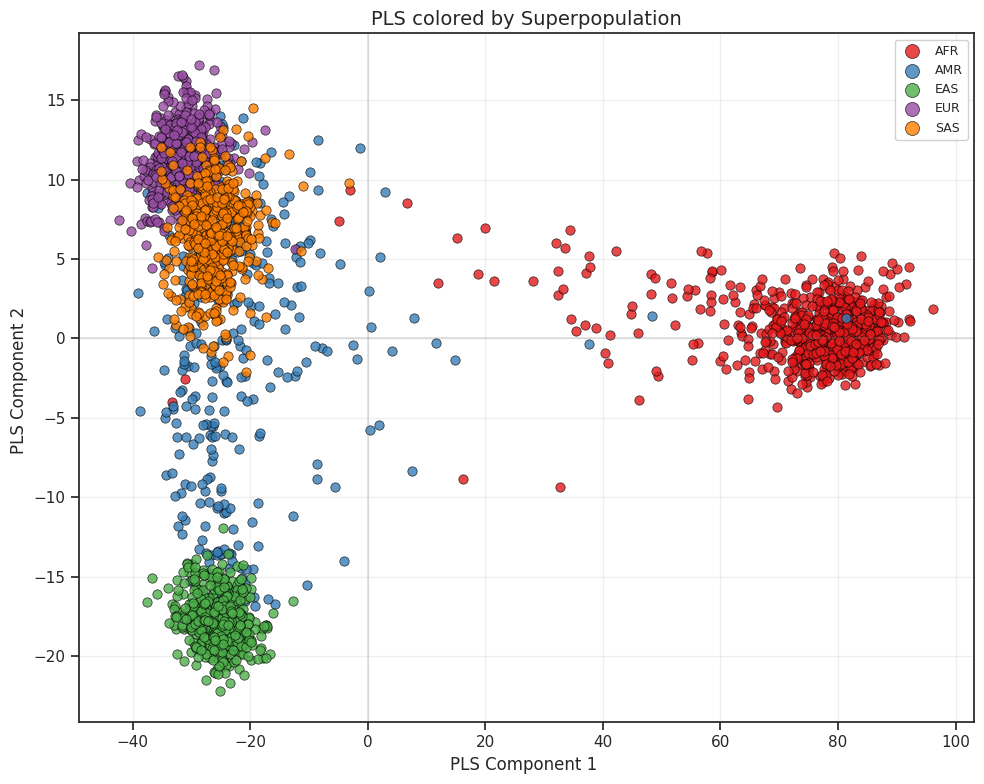

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

colors_scatter = {
    'AFR': '#E41A1C',
    'AMR': '#377EB8',
    'EAS': '#4DAF4A',
    'EUR': '#984EA3',
    'SAS': '#FF7F00'
}

for class_name in le.classes_:
    mask = y == class_name
    ax.scatter(x_scores[mask, 0], x_scores[mask, 1],
               c=colors_scatter.get(class_name, 'gray'),
               label=class_name, alpha=0.8,
               edgecolors='black', linewidth=0.5, s=45)

ax.set_xlabel(f'PLS Component 1 ', fontsize=12)
ax.set_ylabel(f'PLS Component 2 ', fontsize=12)
ax.set_title('PLS colored by Superpopulation', fontsize=14)
ax.legend(loc='best', fontsize=9, framealpha=0.9, markerscale=1.5)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.2)
ax.axvline(x=0, color='gray', linestyle='-', alpha=0.2)

plt.tight_layout()
plt.show()

 PLS проекция генетических данных показываетгенетические взаимосвязи между индивидами из разных суперпопуляций проекта "1000 геномов". Где например AFR - Африка, а расстояние между кластерами, это генетическая дистанция, и тут прекрасно видно что Африка отдалена от всех остальных (по оси x компонента отделяет Африку от Евразии, а компонента по оси y -  Европу от Восточной Азии).

Что примерно ожидается в результате:

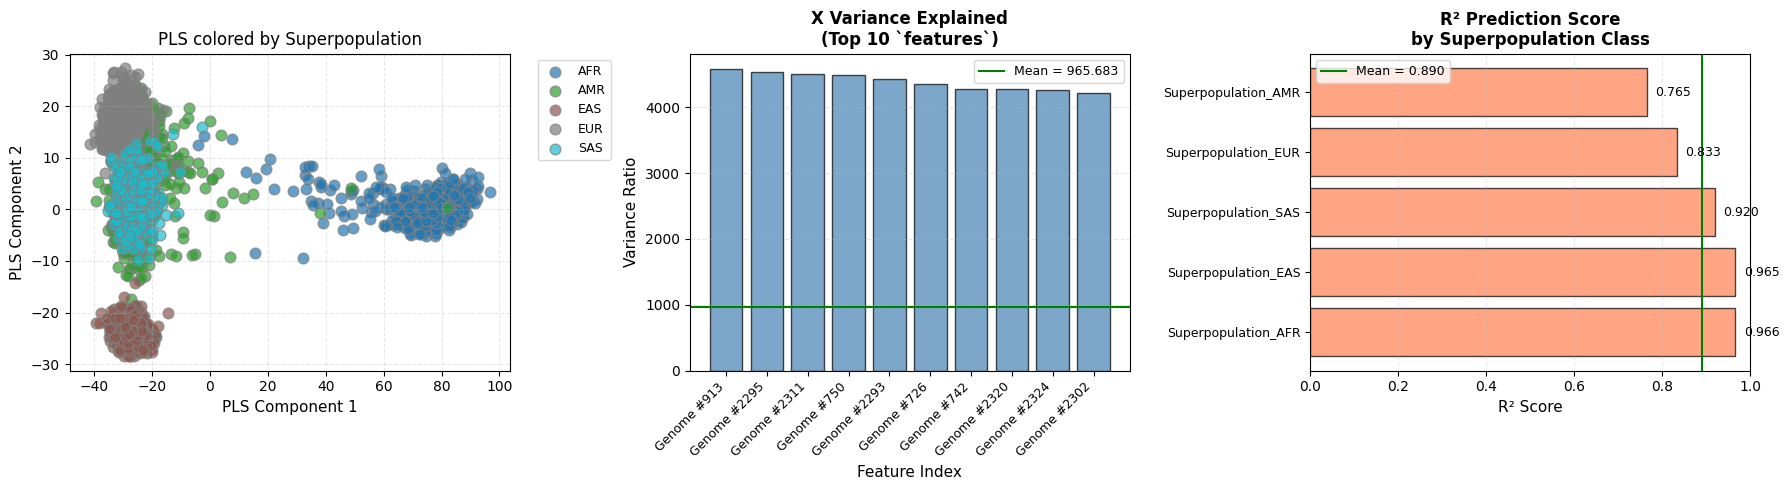

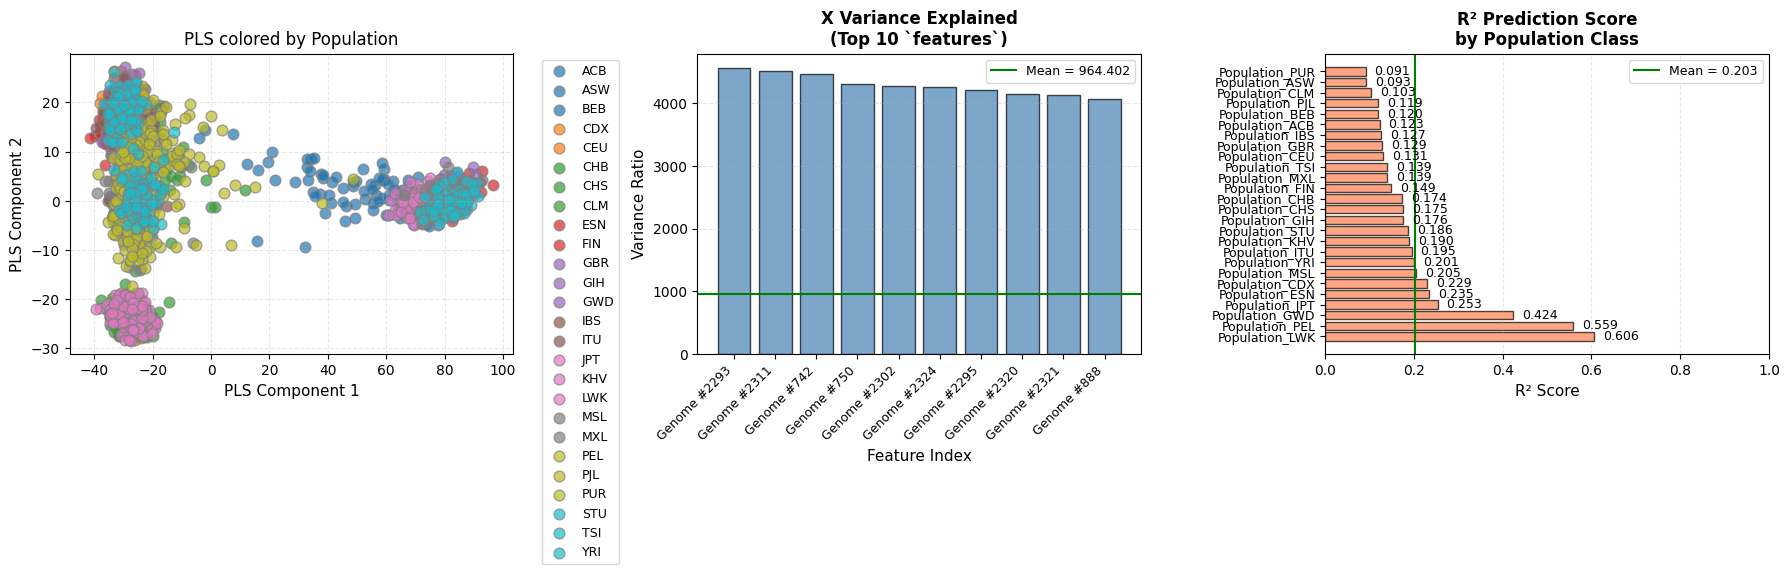